### Import Libraries 

In [42]:
import pandas as pd
import numpy as np

# Visualisation
import seaborn as sns
import matplotlib.pyplot as plt

# Model Data Preprocessing & Encoding
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Model Training
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Model Evaluation
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, roc_curve, classification_report,confusion_matrix, ConfusionMatrixDisplay

# Model Explainability 
import shap

### Load Data

In [24]:
df_model_data = pd.read_parquet(r"C:\Users\leest\OneDrive\Data Projects\Amdari Projects\Digital_Transfer_Fraud_Detection_System\Datasets\Artifats\Modelled_data")

In [25]:
df_model_data.head(3)

,timestamp,home_country,source_currency,dest_currency,channel,amount_usd,new_device,ip_country,location_mismatch,ip_risk_score,...,txn_day_of_week,late_night_hours,amount_high,critical_ip_risk,critical_device_trust,new_account,velocity_spike,chargeback_flag,low_kyc,web_high_amount
0,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,atm,278.19,False,US,False,0.123,...,Monday,0,0,0,0,0,0,0,0,0
1,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,154.29,True,CA,False,0.569,...,Monday,0,0,0,0,0,0,0,0,0
2,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,False,US,False,0.437,...,Monday,0,0,0,0,0,0,0,0,0


In [26]:
df_model_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10940 entries, 0 to 10939
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   timestamp              10940 non-null  datetime64[ns, UTC]
 1   home_country           10940 non-null  object             
 2   source_currency        10940 non-null  object             
 3   dest_currency          10940 non-null  object             
 4   channel                10940 non-null  object             
 5   amount_usd             10940 non-null  float64            
 6   new_device             10940 non-null  bool               
 7   ip_country             10940 non-null  object             
 8   location_mismatch      10940 non-null  bool               
 9   ip_risk_score          10940 non-null  float64            
 10  kyc_tier               10940 non-null  object             
 11  account_age_days       10940 non-null  int64          

### Train-Test Split & Preprocessing

In [27]:
# Sort timestamp chronologically first
df_model_data = df_model_data.sort_values("timestamp").reset_index(drop=True)

# 80/20 split, in chronological order
split_index = int(len(df_model_data) * 0.8)

train_df = df_model_data.iloc[:split_index]
test_df = df_model_data.iloc[split_index:]

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
print(f"\nTrain period: {train_df['timestamp'].min()} to {train_df['timestamp'].max()}")
print(f"Test period:  {test_df['timestamp'].min()} to {test_df['timestamp'].max()}")
print(f"\nTrain fraud rate: {train_df['is_fraud'].mean()*100:.2f}%")
print(f"Test fraud rate:  {test_df['is_fraud'].mean()*100:.2f}%")

Train shape: (8752, 28)
Test shape:  (2188, 28)

Train period: 2022-10-03 18:40:59.468549+00:00 to 2025-03-23 15:23:26.468549+00:00
Test period:  2025-03-23 20:11:35.468549+00:00 to 2025-12-16 00:13:41.468549+00:00

Train fraud rate: 7.77%
Test fraud rate:  14.12%


In [28]:
# Drop target feature

df_model_data = df_model_data.drop(["is_fraud"], axis=1)

In [34]:
categorical_features = df_model_data.select_dtypes(include=["object", "bool"]).columns
categorical_features

Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'new_device', 'ip_country', 'location_mismatch', 'kyc_tier',
       'txn_day_of_week'],
      dtype='object')

In [35]:
numerical_features = df_model_data.select_dtypes(include=["float", "int"]).columns
numerical_features

Index(['amount_usd', 'ip_risk_score', 'account_age_days', 'device_trust_score',
       'risk_score_internal', 'txn_velocity_24h', 'corridor_risk', 'txn_hour',
       'late_night_hours', 'amount_high', 'critical_ip_risk',
       'critical_device_trust', 'new_account', 'velocity_spike',
       'chargeback_flag', 'low_kyc', 'web_high_amount'],
      dtype='object')

In [36]:
all_features = list(categorical_features) + list(numerical_features)
all_features

['home_country',
 'source_currency',
 'dest_currency',
 'channel',
 'new_device',
 'ip_country',
 'location_mismatch',
 'kyc_tier',
 'txn_day_of_week',
 'amount_usd',
 'ip_risk_score',
 'account_age_days',
 'device_trust_score',
 'risk_score_internal',
 'txn_velocity_24h',
 'corridor_risk',
 'txn_hour',
 'late_night_hours',
 'amount_high',
 'critical_ip_risk',
 'critical_device_trust',
 'new_account',
 'velocity_spike',
 'chargeback_flag',
 'low_kyc',
 'web_high_amount']

In [ ]:
# Split train and test data

X_train = train_df[all_features]
y_train = train_df["is_fraud"]

X_test = test_df[all_features]
y_test = test_df["is_fraud"]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

X_train shape: (8752, 26), y_train shape: (8752,)
X_test shape:  (2188, 26), y_test shape:  (2188,)


In [57]:
# Split categorical_features by encoding type needed
ordinal_cols = ["kyc_tier"]
binary_cols = ["new_device", "location_mismatch"]
nominal_cols = ["home_country", "source_currency", "dest_currency", "channel", "ip_country", "txn_day_of_week"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("ord", OrdinalEncoder(categories=[["low", "standard", "enhanced"]]), ordinal_cols),
        ("nom", OneHotEncoder(handle_unknown="ignore", drop="first"), nominal_cols),
        ("bin", FunctionTransformer(lambda x: x.astype(int)), binary_cols),
    ],
    remainder="drop" # Drop any columns not specified to be preprocessed 
)

# Fit only on training data, then transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape:  {X_test_processed.shape}")

X_train_processed shape: (8752, 42)
X_test_processed shape:  (2188, 42)


In [55]:
from sklearn import set_config

set_config(display="diagram")

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

Given the clear rise in fraud rate over time observed during EDA (1.7% in 2022 to 13.4% in 2025), a **chronological split** was used instead of a random split, to realistically simulate how the model would perform when deployed — predicting on future transactions using only past data.

The dataset was sorted by timestamp and split **80/20**, with the earliest 80% of transactions used for training and the most recent 20% held out for testing. As expected, the test set shows a higher fraud rate than the training set, reflecting the genuine shift in fraud behaviour over time rather than a data issue.

Features and target were separated into `X_train`/`y_train` and `X_test`/`y_test`, using a finalised feature list built from the multicollinearity-checked numerical features and the categorical features identified during EDA/Feature Selection.

**Preprocessing was handled with a `ColumnTransformer`**, applying different encoding strategies based on each feature's nature:
- **Numerical features** — scaled with `StandardScaler`
- **`kyc_tier`** — `OrdinalEncoder`, with an explicit order (low < standard < enhanced) to preserve its real risk hierarchy
- **Nominal categoricals** (`home_country`, `source_currency`, `dest_currency`, `channel`, `ip_country`, `txn_day_of_week`) — `OneHotEncoder`, since these categories have no natural order
- **Binary columns** (`new_device`, `location_mismatch`) — cast to integer within the pipeline itself.

The preprocessor was **fit only on the training set**, then applied to the test set, ensuring no information from the test period leaked into how the encoders or scaler were learned.

### Training Logistics Regression

=== Logistic Regression - Baseline (No Imbalance Handling) ===

              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99      1879
       Fraud       1.00      0.92      0.96       309

    accuracy                           0.99      2188
   macro avg       0.99      0.96      0.97      2188
weighted avg       0.99      0.99      0.99      2188

ROC-AUC Score: 0.9812


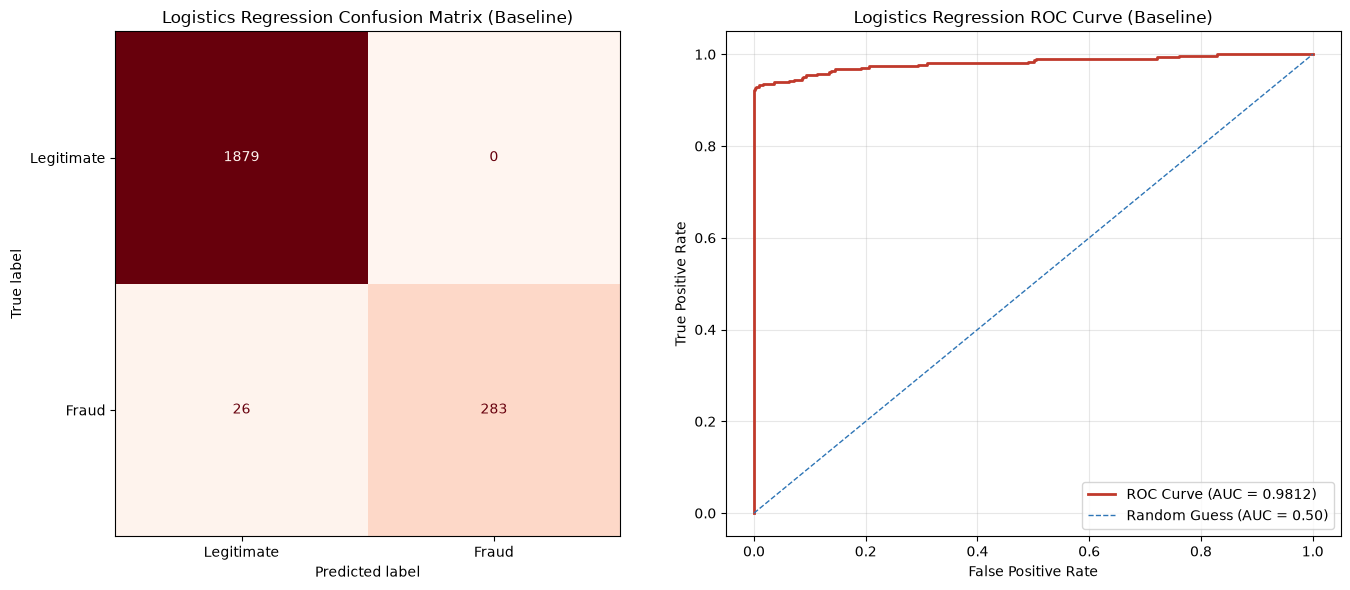

In [53]:
# Build the full pipeline: preprocessing + model, bundled together
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Train
logreg_pipeline.fit(X_train, y_train)

# Predict
y_pred_logreg = logreg_pipeline.predict(X_test)
y_pred_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]  # probability of fraud, for ROC-AUC

# Evaluate
print("=== Logistic Regression - Baseline (No Imbalance Handling) ===\n")
print(classification_report(y_test, y_pred_logreg, target_names=["Legitimate", "Fraud"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_logreg):.4f}")

# Plotting the results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
cm_weighted = confusion_matrix(y_test, y_pred_logreg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_weighted, display_labels=["Legitimate", "Fraud"])
disp.plot(ax=axes[0], cmap="Reds", colorbar=False)
axes[0].set_title("Logistics Regression Confusion Matrix (Baseline)")

# ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_logreg)
auc_score = roc_auc_score(y_test, y_pred_proba_logreg)

axes[1].plot(fpr, tpr, color="#C0392B", linewidth=2, label=f"ROC Curve (AUC = {auc_score:.4f})")
axes[1].plot([0, 1], [0, 1], color="#2E75B6", linestyle="--", linewidth=1, label="Random Guess (AUC = 0.50)")
axes[1].set_title("Logistics Regression ROC Curve (Baseline)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show() 

=== Logistic Regression - With Class Weighting ===

              precision    recall  f1-score   support

  Legitimate       0.99      0.95      0.97      1879
       Fraud       0.77      0.94      0.85       309

    accuracy                           0.95      2188
   macro avg       0.88      0.95      0.91      2188
weighted avg       0.96      0.95      0.96      2188

ROC-AUC Score: 0.9805


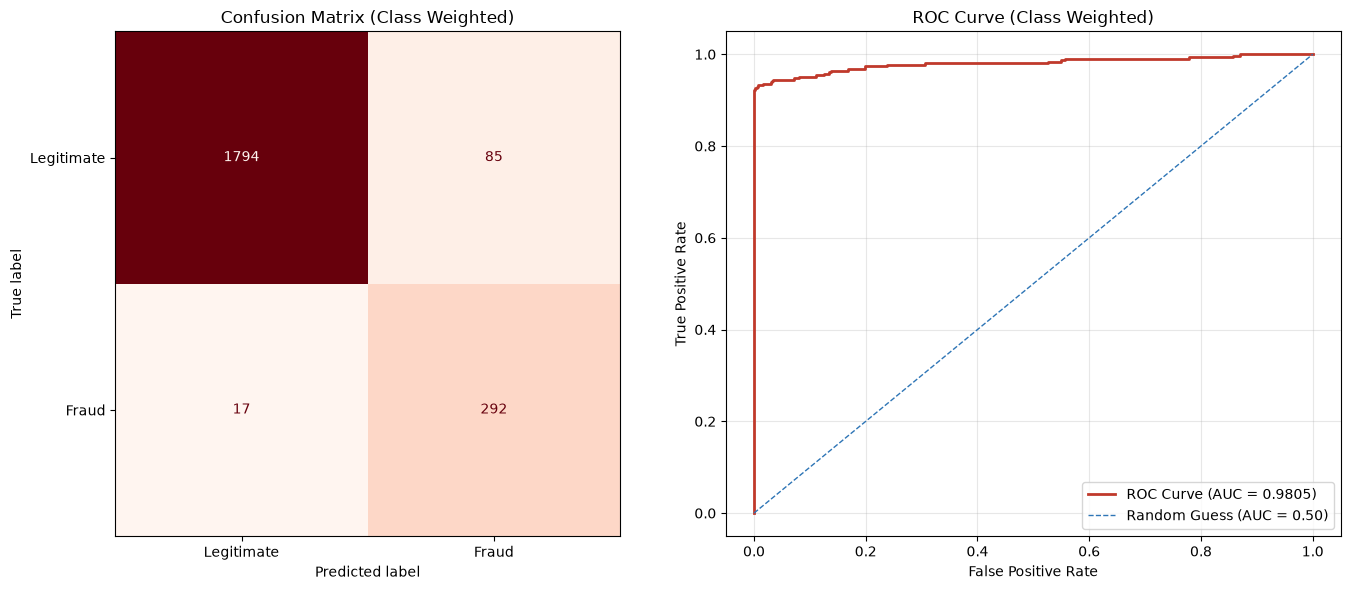

In [49]:
# Logistic Regression with class weighting to handle imbalance
logreg_weighted_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
])

logreg_weighted_pipeline.fit(X_train, y_train)

y_pred_logreg_weighted = logreg_weighted_pipeline.predict(X_test)
y_pred_proba_logreg_weighted = logreg_weighted_pipeline.predict_proba(X_test)[:, 1]

print("=== Logistic Regression - With Class Weighting ===\n")
print(classification_report(y_test, y_pred_logreg_weighted, target_names=["Legitimate", "Fraud"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_logreg_weighted):.4f}")

# Plotting the results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
cm_weighted = confusion_matrix(y_test, y_pred_logreg_weighted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_weighted, display_labels=["Legitimate", "Fraud"])
disp.plot(ax=axes[0], cmap="Reds", colorbar=False)
axes[0].set_title("Confusion Matrix (Class Weighted)")

# ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_logreg_weighted)
auc_score = roc_auc_score(y_test, y_pred_proba_logreg_weighted)

axes[1].plot(fpr, tpr, color="#C0392B", linewidth=2, label=f"ROC Curve (AUC = {auc_score:.4f})")
axes[1].plot([0, 1], [0, 1], color="#2E75B6", linestyle="--", linewidth=1, label="Random Guess (AUC = 0.50)")
axes[1].set_title("ROC Curve (Class Weighted)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Logistic Regression Results

Two versions of Logistic Regression were tested.

**Baseline model (no adjustments):**
- **Caught 92% of all actual fraud cases** (recall) — out of 309 real fraud transactions in the test set, it correctly flagged 284 and missed about 25 (these missed cases are called **false negatives** — fraud that slipped through undetected).
- **Every transaction it flagged as fraud was actually fraud** (100% precision) — **zero false positives**
- **ROC-AUC of 0.98** — near-perfect at ranking risky transactions above safe ones.

**Class-weighted model (adjusted to catch more fraud):**
- **Caught 94% of all actual fraud cases** — slightly better, about 6 more fraud cases caught than the baseline (fewer false negatives).
- **Only 77% of what it flagged as fraud was actually fraud** — meaning roughly 1 in 4 flagged transactions was a **false positive**
- **ROC-AUC stayed almost the same (0.98)** — the model's underlying judgment didn't really improve.

**In plain terms, using the confusion matrix:**
- **False negative** = a real fraud case the model missed → the costly kind of mistake for FinLora directly (financial loss, undetected fraud).
- **False positive** = a legitimate transaction wrongly flagged → the costly kind of mistake for customer experience and analyst workload (unnecessary investigation, customer friction).

The baseline model had **zero false positives** and about **25 false negatives**. The class-weighted model traded some of those false negatives away (down to roughly 19) but introduced far more false positives (over 70), disrupting many more legitimate customer transactions in the process.

**Bottom line:** For the Logistics Regression, the baseline model is the stronger choice — it gives up almost nothing in fraud detection (92% vs 94% caught) while avoiding a large increase in false positives.

### Training Random Forest Classifier 

=== Random Forest - Baseline (No Imbalance Handling) ===

              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99      1879
       Fraud       1.00      0.92      0.96       309

    accuracy                           0.99      2188
   macro avg       0.99      0.96      0.97      2188
weighted avg       0.99      0.99      0.99      2188

ROC-AUC Score: 0.9666


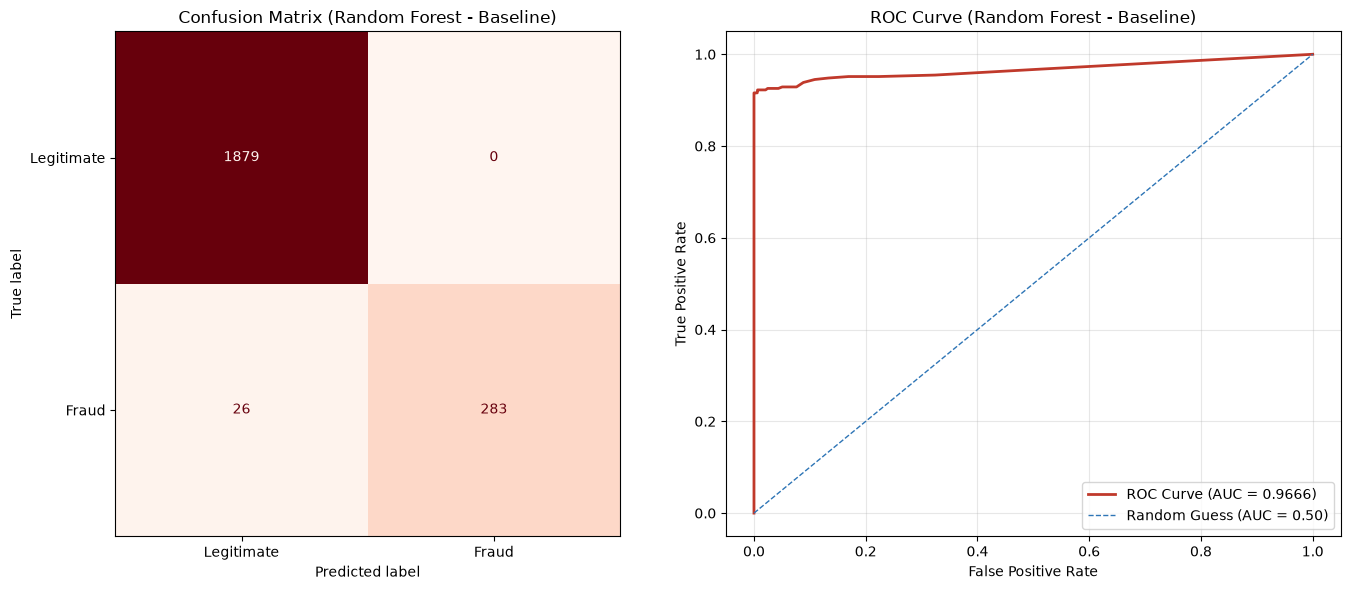

In [73]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", rf_model)
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_pred_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("=== Random Forest - Baseline (No Imbalance Handling) ===\n")
print(classification_report(y_test, y_pred_rf, target_names=["Legitimate", "Fraud"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Legitimate", "Fraud"])
disp.plot(ax=axes[0], cmap="Reds", colorbar=False)
axes[0].set_title("Confusion Matrix (Random Forest - Baseline)")

fpr, tpr, _ = roc_curve(y_test, y_pred_proba_rf)
auc_score = roc_auc_score(y_test, y_pred_proba_rf)
axes[1].plot(fpr, tpr, color="#C0392B", linewidth=2, label=f"ROC Curve (AUC = {auc_score:.4f})")
axes[1].plot([0, 1], [0, 1], color="#2E75B6", linestyle="--", linewidth=1, label="Random Guess (AUC = 0.50)")
axes[1].set_title("ROC Curve (Random Forest - Baseline)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== Random Forest - With Class Weighting ===

              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99      1879
       Fraud       0.99      0.92      0.95       309

    accuracy                           0.99      2188
   macro avg       0.99      0.96      0.97      2188
weighted avg       0.99      0.99      0.99      2188

ROC-AUC Score: 0.9718


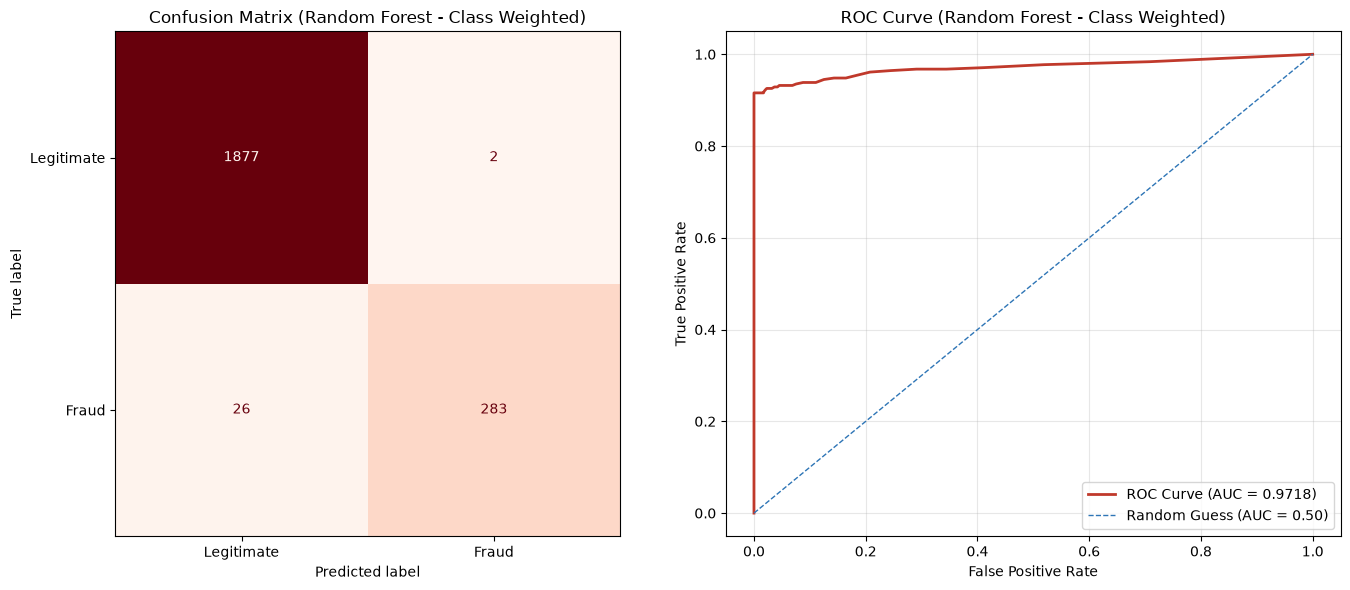

In [74]:
rf_model_weighted = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")

rf_weighted_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", rf_model_weighted)
])

rf_weighted_pipeline.fit(X_train, y_train)

y_pred_rf_weighted = rf_weighted_pipeline.predict(X_test)
y_pred_proba_rf_weighted = rf_weighted_pipeline.predict_proba(X_test)[:, 1]

print("=== Random Forest - With Class Weighting ===\n")
print(classification_report(y_test, y_pred_rf_weighted, target_names=["Legitimate", "Fraud"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_rf_weighted):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_rf_w = confusion_matrix(y_test, y_pred_rf_weighted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_w, display_labels=["Legitimate", "Fraud"])
disp.plot(ax=axes[0], cmap="Reds", colorbar=False)
axes[0].set_title("Confusion Matrix (Random Forest - Class Weighted)")

fpr, tpr, _ = roc_curve(y_test, y_pred_proba_rf_weighted)
auc_score = roc_auc_score(y_test, y_pred_proba_rf_weighted)
axes[1].plot(fpr, tpr, color="#C0392B", linewidth=2, label=f"ROC Curve (AUC = {auc_score:.4f})")
axes[1].plot([0, 1], [0, 1], color="#2E75B6", linestyle="--", linewidth=1, label="Random Guess (AUC = 0.50)")
axes[1].set_title("ROC Curve (Random Forest - Class Weighted)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Random Forest Results

Two versions of Random Forest were tested.

**Baseline model (no adjustments):**
- **Caught 92% of all actual fraud cases** (recall) — out of 309 real fraud transactions in the test set, it correctly flagged 284 and missed about 25 (false negatives).
- **Every transaction it flagged as fraud was actually fraud** (100% precision) — zero false positives.
- **ROC-AUC of 0.967** — strong ability to rank risky transactions above safe ones.

**Class-weighted model:**
- **Caught the same 92% of fraud cases** — recall didn't change.
- **Precision barely moved** (100% → 99%) — only a negligible increase in false positives.
- **ROC-AUC improved slightly** (0.967 → 0.972) — a small gain in how well the model ranks transactions by risk, with no real cost elsewhere.

**Bottom line:** Random Forest is highly stable under class weighting — unlike Logistic Regression, adjusting for imbalance barely changed its precision or recall at all. The class-weighted version is the stronger of the two, offering a modest ranking improvement (higher ROC-AUC) with no meaningful trade-off.

### Training XGBoost Model

=== XGBoost - Baseline (No Imbalance Handling) ===

              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99      1879
       Fraud       0.99      0.92      0.95       309

    accuracy                           0.99      2188
   macro avg       0.99      0.96      0.97      2188
weighted avg       0.99      0.99      0.99      2188

ROC-AUC Score: 0.9755


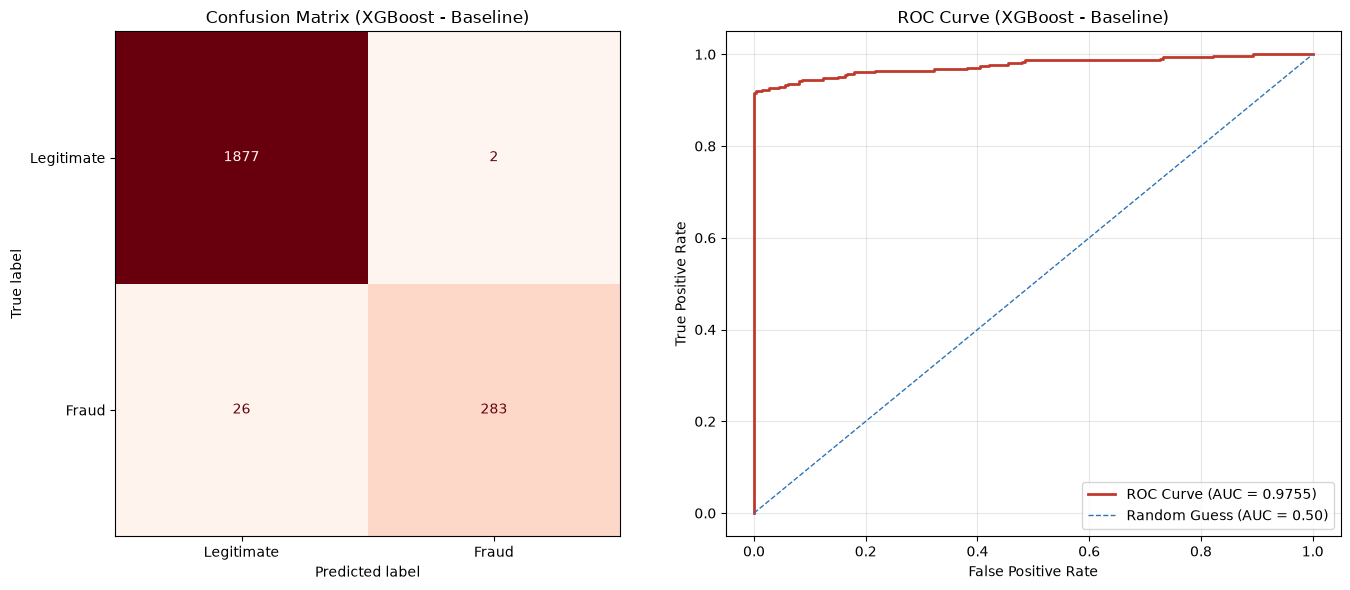

In [78]:
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    max_depth =6,
    learning_rate=0.1,
    eval_metric="logloss"
)

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", xgb_model)
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
y_pred_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("=== XGBoost - Baseline (No Imbalance Handling) ===\n")
print(classification_report(y_test, y_pred_xgb, target_names=["Legitimate", "Fraud"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["Legitimate", "Fraud"])
disp.plot(ax=axes[0], cmap="Reds", colorbar=False)
axes[0].set_title("Confusion Matrix (XGBoost - Baseline)")

fpr, tpr, _ = roc_curve(y_test, y_pred_proba_xgb)
auc_score = roc_auc_score(y_test, y_pred_proba_xgb)
axes[1].plot(fpr, tpr, color="#C0392B", linewidth=2, label=f"ROC Curve (AUC = {auc_score:.4f})")
axes[1].plot([0, 1], [0, 1], color="#2E75B6", linestyle="--", linewidth=1, label="Random Guess (AUC = 0.50)")
axes[1].set_title("ROC Curve (XGBoost - Baseline)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

scale_pos_weight: 11.87

=== XGBoost - With Imbalance Handling ===

              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      1879
       Fraud       0.93      0.92      0.92       309

    accuracy                           0.98      2188
   macro avg       0.96      0.95      0.96      2188
weighted avg       0.98      0.98      0.98      2188

ROC-AUC Score: 0.9703


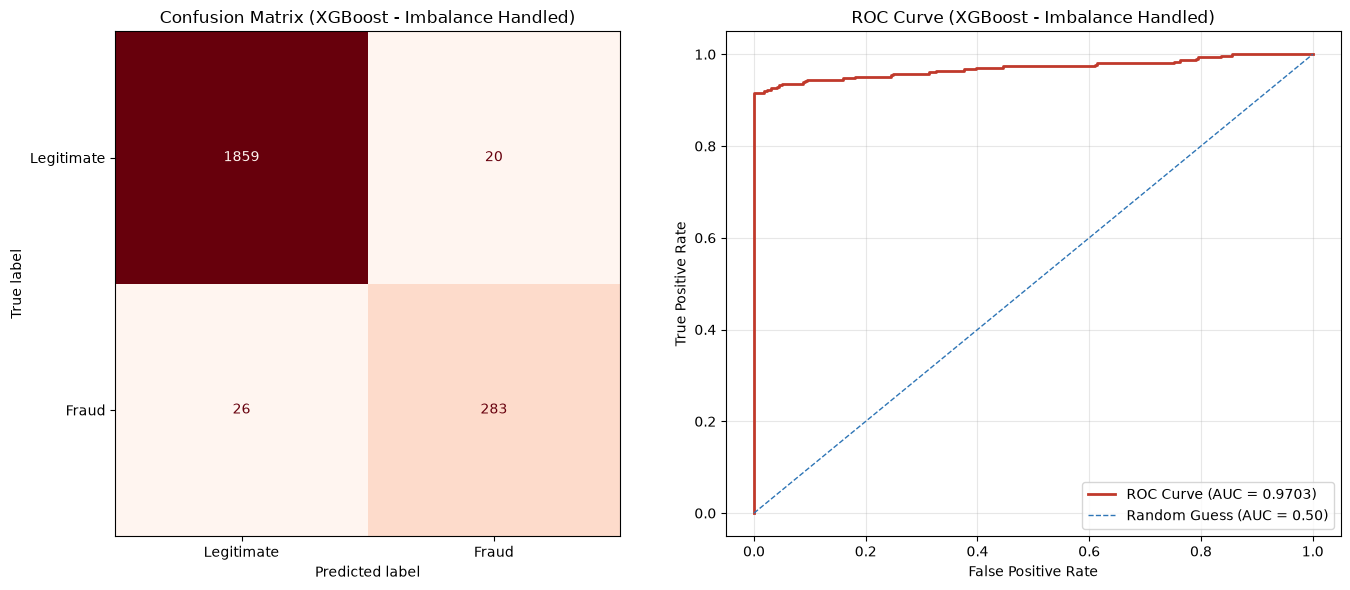

In [77]:
# Calculate the ratio of legitimate to fraud cases in the training set
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model_weighted = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

xgb_weighted_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", xgb_model_weighted)
])

xgb_weighted_pipeline.fit(X_train, y_train)

y_pred_xgb_weighted = xgb_weighted_pipeline.predict(X_test)
y_pred_proba_xgb_weighted = xgb_weighted_pipeline.predict_proba(X_test)[:, 1]

print("\n=== XGBoost - With Imbalance Handling ===\n")
print(classification_report(y_test, y_pred_xgb_weighted, target_names=["Legitimate", "Fraud"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb_weighted):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_xgb_w = confusion_matrix(y_test, y_pred_xgb_weighted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_w, display_labels=["Legitimate", "Fraud"])
disp.plot(ax=axes[0], cmap="Reds", colorbar=False)
axes[0].set_title("Confusion Matrix (XGBoost - Imbalance Handled)")

fpr, tpr, _ = roc_curve(y_test, y_pred_proba_xgb_weighted)
auc_score = roc_auc_score(y_test, y_pred_proba_xgb_weighted)
axes[1].plot(fpr, tpr, color="#C0392B", linewidth=2, label=f"ROC Curve (AUC = {auc_score:.4f})")
axes[1].plot([0, 1], [0, 1], color="#2E75B6", linestyle="--", linewidth=1, label="Random Guess (AUC = 0.50)")
axes[1].set_title("ROC Curve (XGBoost - Imbalance Handled)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

XGBoost Results

Two versions of XGBoost were tested — a baseline model, and a version using `scale_pos_weight` (XGBoost's equivalent of class weighting) to account for the ~9% fraud rate.

**Baseline model (no adjustments):**
- **Caught 92% of all actual fraud cases** (recall) — consistent with both Logistic Regression and Random Forest baselines.
- **99% precision** — almost every flagged transaction was genuinely fraud, with only a small number of false positives.
- **ROC-AUC of 0.976** — strong ranking ability, sitting between Random Forest (0.967) and Logistic Regression (0.981).

**Imbalance-handled model (`scale_pos_weight=11.87`):**
- **Caught the same 92% of fraud cases** — recall didn't improve at all.
- **Precision dropped to 93%** — a real increase in false positives, for no gain in fraud detection.
- **ROC-AUC slightly decreased** (0.976 → 0.970).

**Bottom line:** as with Logistic Regression, explicitly handling class imbalance in XGBoost didn't improve fraud detection — it only introduced more false positives. The baseline XGBoost model is the better of the two, and its 92% recall matches every other model tested so far.

### Model Selection

In [80]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (Baseline)",
        "Logistic Regression (Class Weighted)",
        "Random Forest (Baseline)",
        "Random Forest (Class Weighted)",
        "XGBoost (Baseline)",
        "XGBoost (Imbalance Handled)"
    ],
    "Fraud Precision": [
        precision_score(y_test, y_pred_logreg),
        precision_score(y_test, y_pred_logreg_weighted),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf_weighted),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb_weighted)
    ],
    "Fraud Recall": [
        recall_score(y_test, y_pred_logreg),
        recall_score(y_test, y_pred_logreg_weighted),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf_weighted),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb_weighted)
    ],
    "Fraud F1-Score": [
        f1_score(y_test, y_pred_logreg),
        f1_score(y_test, y_pred_logreg_weighted),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf_weighted),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb_weighted)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_pred_proba_logreg),
        roc_auc_score(y_test, y_pred_proba_logreg_weighted),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_rf_weighted),
        roc_auc_score(y_test, y_pred_proba_xgb),
        roc_auc_score(y_test, y_pred_proba_xgb_weighted)
    ]
}).round(2)

model_comparison

,Model,Fraud Precision,Fraud Recall,Fraud F1-Score,ROC-AUC
0,Logistic Regression (Baseline),1.00,0.92,0.96,0.98
1,Logistic Regression (Class Weighted),0.77,0.94,0.85,0.98
2,Random Forest (Baseline),1.00,0.92,0.96,0.97
3,Random Forest (Class Weighted),0.99,0.92,0.95,0.97
4,XGBoost (Baseline),0.99,0.92,0.95,0.98
5,XGBoost (Imbalance Handled),0.93,0.92,0.92,0.97


**Logistic Regression (Baseline) is the recommended model.**

Across all six models tested, fraud recall is identical (92%) — meaning every model catches the same proportion of actual fraud cases regardless of algorithm or imbalance handling. With recall tied, the deciding factors become precision and ranking quality, and Logistic Regression (Baseline) wins on both: it achieves the **highest precision (100%)** — zero false positives — and the **highest ROC-AUC (0.981)** of any model tested, meaning it's also the most reliable at ranking transactions by risk.

Every attempt at imbalance handling (class weighting, `scale_pos_weight`) either left recall unchanged or reduced precision, with no model successfully improving fraud detection beyond the 92% ceiling. This suggests the engineered features already capture the imbalance problem well, making explicit rebalancing unnecessary.

Logistic Regression also offers a practical advantage beyond the metrics: it's the most interpretable of the three algorithms, with coefficients that clearly show which factors drive each prediction — valuable for building analyst and stakeholder trust in a fraud detection system, and well-aligned with the project's explainability objective.